## Занятие 4
## Математический анализ
## Анализ функции. Построение графика в matplotlib.pyplot
https://matplotlib.org
https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html
https://matplotlib.org/tutorials/text/annotations.html

In [1]:
# Импорт библиотеки matplotlib.pyplot обычно осуществляется так:
import matplotlib.pyplot as plt
from sympy import Symbol, symbols, S, solve, solveset, latex, fraction, Eq
from sympy.calculus.util import continuous_domain
# А для того, чтобы использовать все остальное, сделаем так:
import sympy
import numpy as np

### Задание 1
Найти точки пересечения графика функции $f(x) = (x^2 + 3 x - 2)\log_2(3x+1)$ с осями координат, построить график и отметить точки пересечения.

#### Указание.
Определить функцию как в Примере 3, поскольку нужно будет использовать функцию  $\log_2(x)$ из каждого пакета sympy и numpy.
В numpy использовать $log2(x)$ для вычисления логарифма по основанию 2.

Сроить график только в пределах области определения функции. Точки пересечения с осью OX должны быть не только решениями соответствующего уравнения, но и принадлежать области определения функции.

(-0.3333333333333333, 2.0)

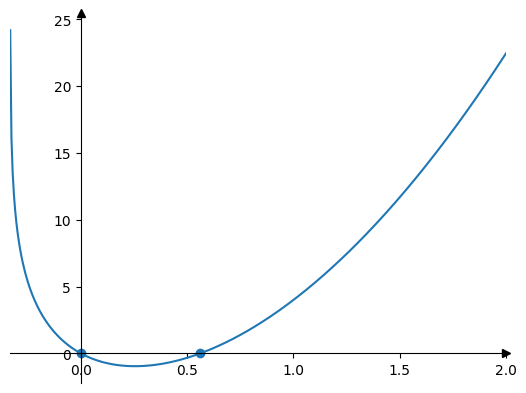

In [80]:
x = Symbol('x')
def f(x, lib='sympy'):
    if lib == 'sympy':
        log = sympy.log
    elif lib == 'numpy':
        log = np.log2
    else:
        return 'Wrong library name, only sympy or numpy is allowed'
    return (x**2 + 3*x - 2) * log(3*x + 1)
solves = solve(f(x))
roots = []
for i in solves:
  if i > -1/3:
    roots.append(i)
point_OY = f(0)
X = np.linspace(-1/3 + 0.001, 2, 400)
Y = f(X, lib='numpy')
y_coord = [0]*len(roots)
ax = plt.gca()
plt.scatter(roots, y_coord)
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position(('data', 0))
ax.spines['left'].set_position(('data', 0))
ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)
plt.plot(X, Y)
ax.set_xlim(-1/3, 2)

### Задание 2
Найти асимптоты графика функции $g(x) = \frac{35x^2 + 4x - 15}{3x - 2}$, построить график и асимптоты, в легенду графика включить формулы функции и асимптот, подписать оси 'x' и 'y'.

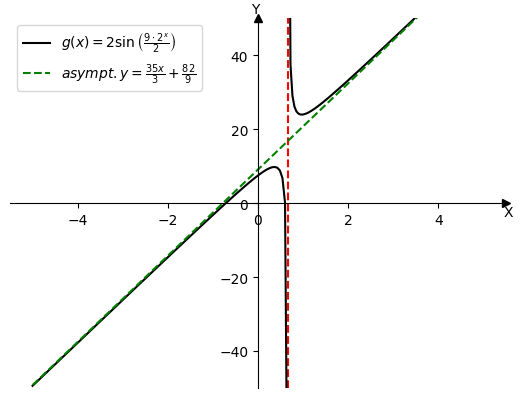

In [10]:
x = Symbol('x')
def g(x):
  return (35*x**2 + 4*x - 15) / (3*x - 2)
gnum, gdenom = sympy.fraction(g(x))
v_as = sympy.solve(gdenom, x)
y0pos = g(x).limit(x, +sympy.oo)
y0neg = g(x).limit(x, -sympy.oo)
kpos = sympy.limit(g(x)/x, x, +sympy.oo)
kneg = sympy.limit(g(x)/x, x, -sympy.oo)
if kpos == kneg:
    k = kpos
else:
    k = (kneg, kpos)
b = sympy.limit(g(x) - k*x, x, sympy.oo)
y_as = k*x + b
minY = -50
maxY = 50
ax = plt.gca()
ax.set(ylim=(minY, maxY))
ax.set_xlabel('X')
ax.set_ylabel('Y', rotation=0)
ax.xaxis.set_label_coords(1.005, 0.495)
ax.yaxis.set_label_coords(0.495, 1.005)
for item in v_as:
    ax.axvline(x=item, color='red', linestyle='--')
X1 = np.linspace(-5, float(item - 0.01), 100)
X2 = np.linspace(float(item + 0.01), 5, 100)
Y1 = g(X1)
Y2 = g(X2)
ax.plot(X1, Y1, 'k-', label=r'$g(x)=' + sympy.latex(f(x)) + r'$')
ax.plot(X2, Y2, 'k-')
ax.plot([X1[0], X2[-1]], [y_as.subs(x, X1[0]), y_as.subs(x, X2[-1])], 'g--',
         label=r'$asympt. y=' + sympy.latex(y_as) + r'$')
ax.legend(loc='best')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position(('data', 0))
ax.spines['left'].set_position(('data', 0))
ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)

### Задание 3.
Описать в виде функции траекторию пули, выпущенной со скоростью $v_0$ под углом $\alpha$ к горизонту (по умолчанию $v_0 = 0$, $\alpha = \pi/2$)
$$
\left\{
\begin{matrix}
x=v_0t\cos\alpha\\
y=v_0t\sin\alpha-\frac{10t^2}{2}
\end{matrix}
\right.
$$
Аргументы функции $t$, $v_0$ и $\alpha$, результат - два выражения $x$ и $y$, в соответствии с формулами, приведенными выше.

Определить соответствующий набору параметров $v_0$ и $\alpha$ диапазон значений параметра времени $t$, учитывая, что пуля не должна провалиться сквозь землю.

Построить траектории при заданных значениях начальной скорости и угла на одном графике (($v_0 = 1$, $\alpha = \pi/6$), ($v_0 = 2$, $\alpha= \pi/4$), ($v_0 = 2$, $\alpha = 1$)). Графики должны быть соответственно зеленого, красного и черного цвета.

Подписать оси $x$, $y$.

В легенде отразить значения параметров, например, $v_0 = 2,\ \alpha = \pi/6$.

Название графика - Траектории пуль.
#### Указание.
Использовать $\sin$ из numpy.

Решить уравнение $y = 0$ относительно $t$, пользуясь solve или solveset, чтобы с помощью найденного значения $t$ определить правую границу значений $x$.

#### Решение.
Определим функцию, зададим списком данные наборы параметров ($v_0 = 1$, $\alpha = \pi/6$), ($v_0 = 2$, $\alpha= \pi/4$), ($v_0 = 2.5$, $\alpha = 1$) и найдем значение параметра $t$, при котором  $y = 0$. Затем подстановкой subs в t_interval найдем наибольшее значение $t$ и построим графики:

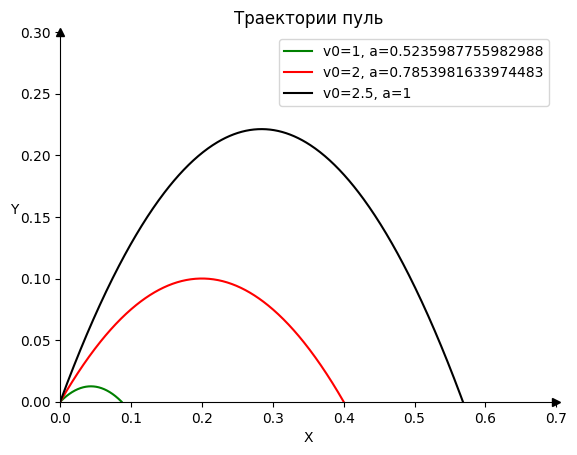

In [9]:
def trajectory(t, v_0=0, alpha=np.pi/2):
  x = v_0 * t * np.cos(alpha)
  y = v_0 * t * np.sin(alpha) - 10 * t**2 / 2
  return x, y
parametrs = [(1, np.pi/6), (2, np.pi/4), (2.5, 1)]
t = symbols('t')
ax = plt.gca()
ax.set_xlabel('X')
ax.set_ylabel('Y', rotation=0)
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position(('data', 0))
ax.spines['left'].set_position(('data', 0))
ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)
ax.set_ylim(0, 0.3)
ax.set_xlim(0, 0.7)
ax.set_title(r'Траектории пуль')
for v_0, alpha in parametrs:
  y_eq = Eq(v_0 * t * np.sin(alpha) - 10 * t**2 / 2, 0)
  t_solve = solve(y_eq, t)
  t_max = max(t_solve) if t_solve else 0
  t_values = np.linspace(0, float(t_max), num=500)
  X, Y = trajectory(t_values, v_0, alpha)
  if v_0 == 1:
    color = 'green'
  elif v_0 == 2:
    color = 'red'
  else:
    color = 'black'
  plt.plot(X, Y, color=color, label=f'v0={v_0}, a={alpha}')
  ax.legend(loc='upper right')

### Индивидуальное задание.
Построить в одной координатной плоскости графики функций.

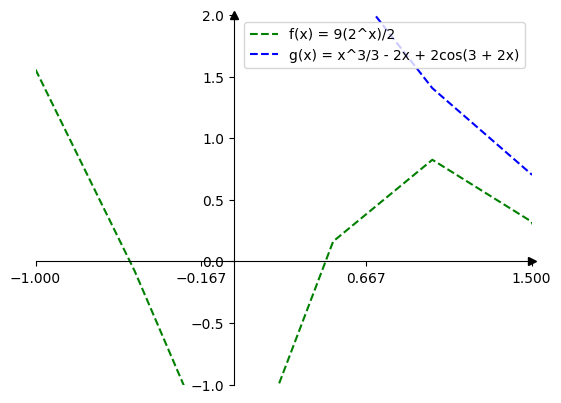

In [56]:
def f(x, lib='sympy'):
    if lib == 'sympy':
        sin = sympy.sin
    elif lib == 'numpy':
        sin = np.sin
    else:
        return 'Wrong library name, only sympy or numpy is allowed'
    return 2*sin((9*2**x)/2)
def g(x, lib='sympy'):
    if lib == 'sympy':
        cos = sympy.cos
    elif lib == 'numpy':
        cos = np.cos
    else:
        return 'Wrong library name, only sympy or numpy is allowed'
    return x**3/3 - 2*x + 2*(cos(2*x/3)) + 3/2
X = np.arange(-1, 3.5, 0.5)
Y_f = f(X, lib='numpy')
Y_g = g(X, lib='numpy')
ax = plt.gca()
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position(('data', 0))
ax.spines['left'].set_position(('data', 0))
ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)
ax.plot(X, Y_f, 'g--', label='f(x) = 9(2^x)/2')
ax.plot(X, Y_g, 'b--', label='g(x) = x^3/3 - 2x + 2cos(3 + 2x)')
ax.set_xticks([-1, -1/6, 2/3, 3/2])
ax.set_ylim(-1, 2)
ax.set_xlim(-1, 3/2)
ax.legend(loc='upper right')